In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.Resize(128),
    transforms.ToTensor()
])

In [3]:
dataset = datasets.ImageFolder(
    root="./data/images_128",
    transform=transform
)

In [4]:
dataloader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    persistent_workers=True,
    prefetch_factor=2,
    num_workers=2,
    pin_memory=True
)

In [5]:
import time


for i, (x, y) in enumerate(dataloader):
    start = time.time()
    print(f"{i+1} batch load time: {time.time()-start}")
    if i==1: break

1 batch load time: 2.384185791015625e-06
2 batch load time: 2.1457672119140625e-06


In [6]:
x, y = next(iter(dataloader))
print(x.mean(), x.std())

tensor(0.4626) tensor(0.2583)


In [7]:
len(dataloader)

719

In [8]:
class CnnModel (nn.Module):
    def __init__(self):
        # initialize super 
        super().__init__()
        
        # Kernel
        self.kernel1 = nn.Conv2d(
            in_channels=3,
            out_channels=8,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.bn1 = nn.BatchNorm2d(8)
        
        self.kernel2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.bn2 = nn.BatchNorm2d(16)
        
        self.kernel3 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.bn3 = nn.BatchNorm2d(32)
        
        self.kernel4 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
        )
        self.bn4 = nn.BatchNorm2d(64)
        
        # Linear neural networks
        self.W1 = nn.Parameter(torch.randn(64*8*8, 8) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(8))
        
        self.W2 = nn.Parameter(torch.randn(8, 2) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(2))

        # loss function
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        
    def forward(self, x):
        
        # first kernel
        x = self.kernel1(x)
        x = self.bn1(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        
        # second kernel
        x = self.kernel2(x)
        x = self.bn2(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        
        # third kernel
        x = self.kernel3(x)
        x = self.bn3(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
        
        # fourth kernel
        x = self.kernel4(x)
        x = self.bn4(x)
        x = nn.functional.relu(x)
        x = nn.functional.max_pool2d(x, 2)
                
        # reshape images
        x = x.reshape((x.shape[0], -1))
        
        x = x @ self.W1 + self.b1
        x = nn.functional.relu(x)
        
        x = x @ self.W2 + self.b2
                
        return x
    
    def compute_loss(self, y_hat, y):        
        # loss calling
        loss = self.criterion(y_hat, y)
        return loss
    
    def backward_propagation(self, loss, learning_rate=0.001):
        # start loss backward
        loss.backward()
        
        with torch.no_grad():
            for param in self.parameters():
                if param.grad is not None:
                    param.data -= learning_rate * param.grad
                    param.grad.zero_()
        
        return loss.item()

In [9]:
def train_epoch(model, dataloader,learning_rate=0.001):
    # using for loop to access each batch
    costs = []
    for x, y in dataloader:
        # transfer to cuda
        x = x.to("cuda", non_blocking=True)
        y = y.to("cuda", non_blocking=True)
        
        #code to stop tracking grad during backtrack
        y_hat = model.forward(x)
        loss = model.compute_loss(y_hat, y)
        cost = model.backward_propagation(loss, learning_rate)
        costs.append(cost)
    
    return costs

In [10]:
# initialize model
model = CnnModel().to("cuda")

In [11]:
import time
import numpy as np

costs = []

In [12]:
for i in range(0, 100):
    #start time
    start = time.time()
    epoch = train_epoch(model, dataloader=dataloader, learning_rate=0.005)
    #end time
    end = time.time()
    cost = np.mean(np.array(epoch))
    
    costs.append(cost)
    
    if (i+1)%10 ==0:
        # model save name
        file_name = f"model_epoch_{i+1}"
        # print loss in every 10 epochs        
        print(f"{(i+1)} Epoch Loss ====> {cost} in {end-start}s per epoch.")
        # save the model
        torch.save(model.state_dict(), f"./model1/{file_name}.pth")
        print(f"Saved model {file_name}")
        

10 Epoch Loss ====> 0.40822800297564693 in 6.858208417892456s per epoch.
Saved model model_epoch_10
20 Epoch Loss ====> 0.3259413545751771 in 6.902823209762573s per epoch.
Saved model model_epoch_20
30 Epoch Loss ====> 0.2660620707256903 in 6.934374570846558s per epoch.
Saved model model_epoch_30
40 Epoch Loss ====> 0.23551964631332642 in 6.940774440765381s per epoch.
Saved model model_epoch_40
50 Epoch Loss ====> 0.22228280841392337 in 7.01259708404541s per epoch.
Saved model model_epoch_50
60 Epoch Loss ====> 0.2163010482910777 in 6.990084409713745s per epoch.
Saved model model_epoch_60
70 Epoch Loss ====> 0.21282650731369251 in 6.9536521434783936s per epoch.
Saved model model_epoch_70
80 Epoch Loss ====> 0.2107888293324326 in 6.987233400344849s per epoch.
Saved model model_epoch_80
90 Epoch Loss ====> 0.20895032221982476 in 6.679216623306274s per epoch.
Saved model model_epoch_90
100 Epoch Loss ====> 0.20767293277718593 in 6.649742126464844s per epoch.
Saved model model_epoch_100


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

epoch = [i+1 for i in range(len(costs))]

display(len(costs))
display(len(epoch))

100

100

<Axes: title={'center': 'Loss Drop function!'}, xlabel='Epoch', ylabel='Loss'>

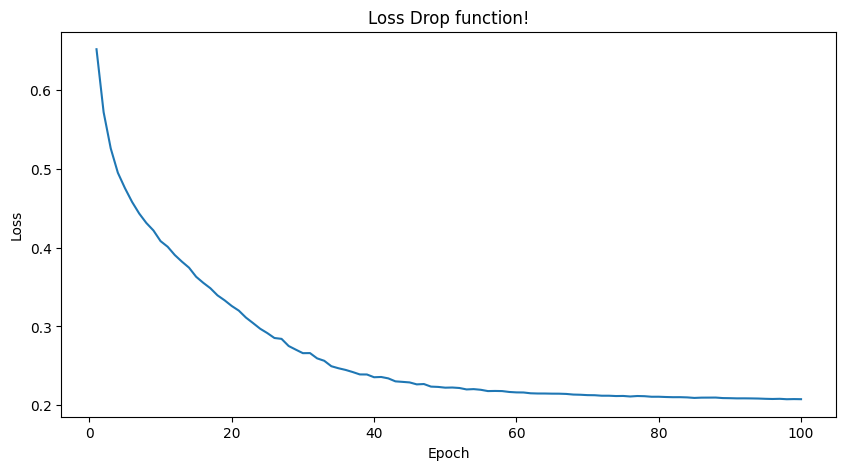

In [14]:

df = pd.DataFrame({"x":epoch, "y":costs})

plt.figure(figsize=(10,5))
plt.title("Loss Drop function!")
plt.ylabel("Loss")
plt.xlabel("Epoch")
sns.lineplot(df, x="x", y="y")

In [15]:
#test model

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root="./data/valid",
    transform=test_transforms
)

test_dataloader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True, 
    prefetch_factor=2, 
    persistent_workers=True
)

print(len(test_dataset))
print(len(test_dataloader))

2000
63


In [16]:
def evaluate_model(model, dataloader, device="cuda"):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    criterion = torch.nn.CrossEntropyLoss()

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            # loss (optional but useful)
            loss = criterion(outputs, y)
            total_loss += loss.item()

            # predictions
            preds = torch.argmax(outputs, dim=1)

            # store results
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    # combine all batches
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    avg_loss = total_loss / len(dataloader)

    return all_preds, all_labels, avg_loss

In [17]:
def classification_metrics(y_pred, y_true):
    """
    y_pred: tensor of predicted labels (0/1)
    y_true: tensor of true labels (0/1)
    """

    y_pred = y_pred.cpu()
    y_true = y_true.cpu()

    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    tn = ((y_pred == 0) & (y_true == 0)).sum().item()
    fp = ((y_pred == 1) & (y_true == 0)).sum().item()
    fn = ((y_pred == 0) & (y_true == 1)).sum().item()

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    print("==== Confusion Matrix ====")
    print(f"TP: {tp}  FP: {fp}")
    print(f"FN: {fn}  TN: {tn}")
    print()
    print("==== Metrics ====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return {
    "tp": tp,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1
    }

In [23]:
scores = []

for i in range(10):
    #load model
    test_model = CnnModel().to("cuda")
    test_model.load_state_dict(torch.load(f"./model1/model_epoch_{(i+1)*10}.pth"))

    y_pred, y_true, avg_loss = evaluate_model(test_model, test_dataloader)
    print(f"model_epoch_{(i+1)*10} Avg Loss => {avg_loss}")
    
    
    score = classification_metrics(y_pred=y_pred, y_true=y_true)
    score["loss"] = avg_loss
    score['epoch'] = (i+1)*10
    scores.append(score)
    
    print(f"\n\nmodel_epoch_{(i+1)*10} scores:")
    print(score)

model_epoch_10 Avg Loss => 0.4773042504749601
==== Confusion Matrix ====
TP: 938  FP: 400
FN: 62  TN: 600

==== Metrics ====
Accuracy : 0.7690
Precision: 0.7010
Recall   : 0.9380
F1 Score : 0.8024


model_epoch_10 scores:
{'tp': 938, 'tn': 600, 'fp': 400, 'fn': 62, 'accuracy': 0.7689999999961551, 'precision': 0.7010463378123988, 'recall': 0.93799999999062, 'f1': 0.8023952046784739, 'loss': 0.4773042504749601, 'epoch': 10}
model_epoch_20 Avg Loss => 0.45445919935665435
==== Confusion Matrix ====
TP: 659  FP: 62
FN: 341  TN: 938

==== Metrics ====
Accuracy : 0.7985
Precision: 0.9140
Recall   : 0.6590
F1 Score : 0.7658


model_epoch_20 scores:
{'tp': 659, 'tn': 938, 'fp': 62, 'fn': 341, 'accuracy': 0.7984999999960075, 'precision': 0.9140083217626351, 'recall': 0.65899999999341, 'f1': 0.7658338126704439, 'loss': 0.45445919935665435, 'epoch': 20}
model_epoch_30 Avg Loss => 0.3594783352954047
==== Confusion Matrix ====
TP: 878  FP: 197
FN: 122  TN: 803

==== Metrics ====
Accuracy : 0.8405
Pr

In [24]:
import pandas as pd

scores = pd.DataFrame(scores)

scores

,tp,tn,fp,fn,accuracy,precision,recall,f1,loss,epoch
0,938,600,400,62,0.7690,0.701046,0.938,0.802395,0.477304,10
1,659,938,62,341,0.7985,0.914008,0.659,0.765834,0.454459,20
2,878,803,197,122,0.8405,0.816744,0.878,0.846265,0.359478,30
3,648,949,51,352,0.7985,0.927039,0.648,0.762802,0.474563,40
4,955,624,376,45,0.7895,0.717506,0.955,0.819391,0.502450,50
5,827,842,158,173,0.8345,0.839594,0.827,0.833249,0.374131,60
6,823,844,156,177,0.8335,0.840654,0.823,0.831733,0.380097,70
7,840,827,173,160,0.8335,0.829220,0.840,0.834575,0.382087,80
8,827,820,180,173,0.8235,0.821251,0.827,0.824116,0.391196,90
9,843,799,201,157,0.8210,0.807471,0.843,0.824853,0.399071,100


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

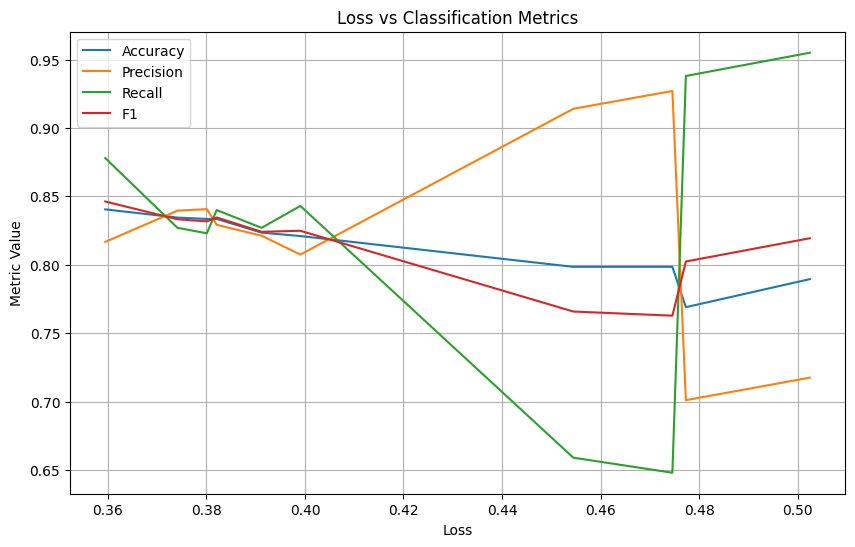

In [26]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=scores, x="loss", y="accuracy", label="Accuracy")
sns.lineplot(data=scores, x="loss", y="precision", label="Precision")
sns.lineplot(data=scores, x="loss", y="recall", label="Recall")
sns.lineplot(data=scores, x="loss", y="f1", label="F1")

plt.title("Loss vs Classification Metrics")
plt.xlabel("Loss")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(True)
plt.show()

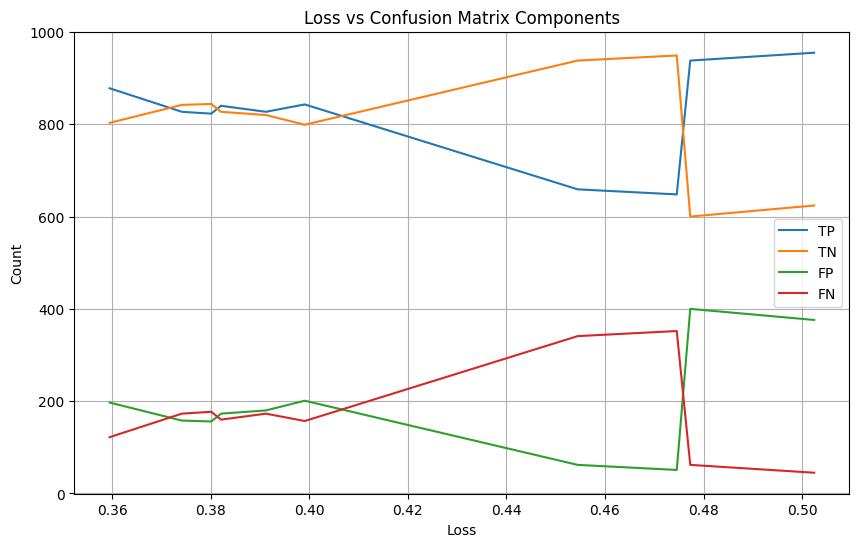

In [27]:
plt.figure(figsize=(10, 6))

sns.lineplot(data=scores, x="loss", y="tp", label="TP")
sns.lineplot(data=scores, x="loss", y="tn", label="TN")
sns.lineplot(data=scores, x="loss", y="fp", label="FP")
sns.lineplot(data=scores, x="loss", y="fn", label="FN")

plt.title("Loss vs Confusion Matrix Components")
plt.xlabel("Loss")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

<Axes: xlabel='epoch', ylabel='loss'>

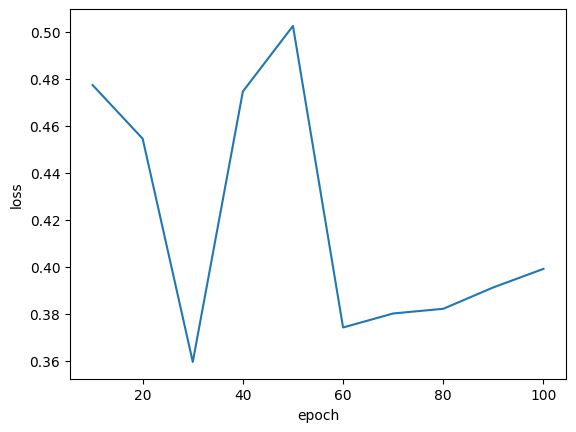

In [30]:
sns.lineplot(data=scores, x="epoch", y="loss")

<Axes: xlabel='epoch', ylabel='f1'>

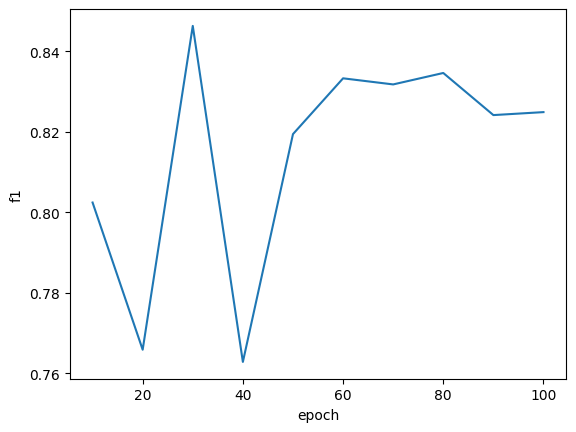

In [29]:

sns.lineplot(data=scores, x="epoch", y="f1")